<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/latihanNo1bJobsheet8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from google.colab import files
import io

In [46]:
uploaded = files.upload()

Saving DatasetSIB2GbyLovie.csv to DatasetSIB2GbyLovie (5).csv


In [49]:
df = pd.read_csv('DatasetSIB2GbyLovie.csv')

In [50]:
# menghapus data pada baris ke-20 karena mengandung NaN
df = df.drop(index=20)
df = df.dropna(subset=['Usia', 'BBM_Per_Bulan', 'IPK', 'Tinggi badan', 'Berat badan'])

print(f"\nBaris ke-20 telah dihapus. Jumlah data sekarang: {len(df)}")


Baris ke-20 telah dihapus. Jumlah data sekarang: 20


In [60]:
features = ['Tinggi badan', 'Berat badan']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

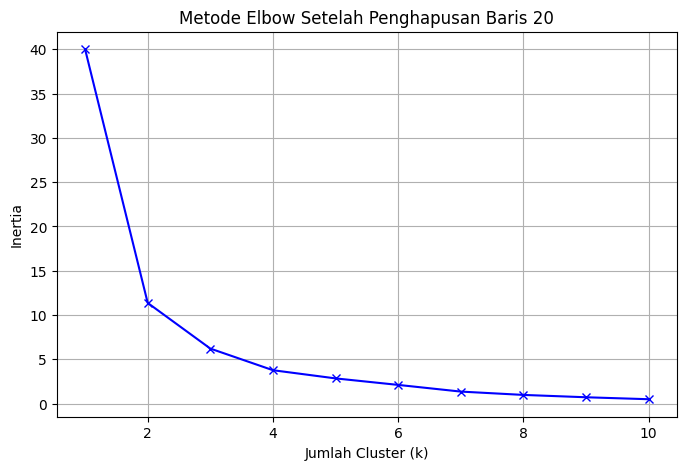

In [61]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow Setelah Penghapusan Baris 20')
plt.grid(True)
plt.show()

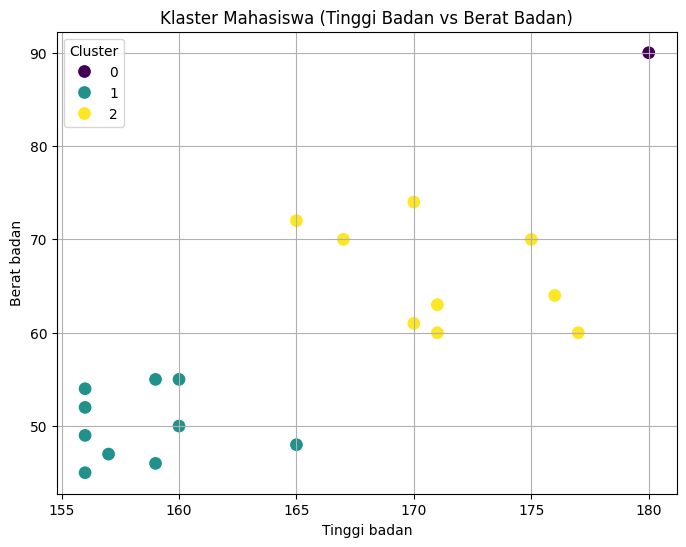

In [62]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Tinggi badan'], y=df['Berat badan'], hue=df['Cluster'], palette='viridis', s=100)
plt.title('Klaster Mahasiswa (Tinggi Badan vs Berat Badan)')
plt.grid(True)
plt.show()

In [63]:
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}[cite: 11]")
print(f"Inertia (k={k_optimal}): {kmeans.inertia_:.3f}[cite: 11]")


Silhouette Score: 0.604[cite: 11]
Inertia (k=3): 6.206[cite: 11]
